# Fixation mRNN Hidden-Unit Sweep

This notebook tests how many Elman hidden units per region are needed to fit fixation-aligned neural activity PCs. The decisions from the smoke-test notebook are fixed here:

- Input is only the 3 fixation-condition one-hot channels.
- There are no Gaussian temporal basis channels.
- The target is the shared 42-dimensional PC representation of normalized firing rates for each region.
- Training runs for 25,000 iterations.
- First- and second-derivative loss weights are both 1.

The sweep trains 20, 30, 40, and 50 hidden units per region, then compares reconstruction quality, temporal-dynamics quality, and parameter-adjusted criteria.

## 1. Setup

In [1]:
from pathlib import Path
from dataclasses import replace
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    load_fixation_mrnn_config,
    make_targets,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    settings_from_config,
    train_fixation_mrnn_scratch,
    variance_comparison,
)
from dal_monte_2022_analysis.ephys.plotting import FixationMRNNDiagnosticPlotSettings


def display_figure(fig, *, dpi=95):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


CONDITION_COLORS = {
    "face_interactive": "#b64198",
    "face_non_interactive": "#4c9a2a",
    "object": "#6f4e37",
}


## 2. Sweep Settings

In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
base_settings = settings_from_config(cfg)
base_settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
base_settings.device = "auto"
base_settings.target_mode = "region_pcs"
base_settings.temporal_basis_count = 0
base_settings.epochs = 20_000
base_settings.lr = 1e-4
base_settings.temporal_derivative_loss_scale = 1.0
base_settings.temporal_curvature_loss_scale = 1.0
# L1 regularization is important for this dataset, since the number of units is
# large and we want to encourage sparsity in the representations. However, we 
# found that too much L1 regularization can lead to underfitting, so we set the
# rate scale to 0 and only use a small weight scale.
base_settings.l1_weight_scale = 0.0  # or 1e-4
base_settings.l1_rate_scale = 0.0

# The spectral radius controls the stability of the dynamics.
# A value less than 1 encourages stable dynamics, while a value
# of 1 allows for more complex dynamics but can be harder to
# train. We found that a value of 0.9 works well for this dataset,
# but you can experiment with values closer to 1 if you want to
# encourage more complex dynamics.
base_settings.spectral_radius = 1.2  # or 1.0

base_settings.initialization_mode = "single"
base_settings.overwrite_seed_plan = False
base_settings.train_initial_state = True

hidden_unit_grid = [40, 50, 60]
base_seed = 123456
scratch_prefix = "hidden_unit_sweep_region_pcs_condition_only"

base_settings


FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', region_order=('ofc', 'bla', 'dmpfc', 'accg'), condition_order=('face_interactive', 'face_non_interactive', 'object'), target_mode='region_pcs', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, temporal_basis_count=0, hidden_units=100, activation='softplus', spectral_radius=1.2, rec_constrained=False, inp_constrained=False, batch_first=True, inp_noise=0.0, act_noise=0.0, epochs=20000, lr=0.0001, loss_fn='mse', temporal_derivative_loss_scale=1.0, temporal_curvature_loss_scale=1.0, pre_fixation_loss_weight=1.0, post_fixation_loss_weight=1.0, l1_weight_scale=0.0,

## 3. Target Audit

This cell verifies the two key assumptions before training: the input has only the 3 condition channels, and the region-PC target has 42 PCs per region. If the PC count changes, stop here and decide whether to change the target builder or the variance threshold.

In [3]:
targets = make_targets(base_settings)
pc_dims = {region: targets.pcs_by_region[region].shape[-1] for region in targets.region_order}
summary_rows = []
for region in targets.region_order:
    pca = targets.pca_by_region[region]
    summary_rows.append({
        "region": region,
        "pc_target_shape": targets.pcs_by_region[region].shape,
        "shared_pc_dims": pc_dims[region],
        "pcs_required_for_95pct": pca.n_components_required,
        "explained_variance_in_saved_pcs": float(np.sum(pca.explained_variance_ratio)),
        "target_variance": float(np.var(targets.pcs_by_region[region])),
    })

print("Input tensor shape:", targets.input_tensor.shape)
print("Input channels: 3 condition one-hot +", targets.input_tensor.shape[-1] - 3, "temporal channels")
display(pd.DataFrame(summary_rows))

assert targets.input_tensor.shape[-1] == 3, "Expected condition-only input with exactly 3 channels."
assert len(set(pc_dims.values())) == 1, f"Expected shared PC count across regions, got {pc_dims}."
assert next(iter(pc_dims.values())) == 42, f"Expected 42 PCs per region, got {pc_dims}."


Input tensor shape: (3, 100, 3)
Input channels: 3 condition one-hot + 0 temporal channels


,region,pc_target_shape,shared_pc_dims,pcs_required_for_95pct,explained_variance_in_saved_pcs,target_variance
0,ofc,"(3, 100, 42)",42,38,0.962860,0.013428
1,bla,"(3, 100, 42)",42,42,0.950282,0.024063
2,dmpfc,"(3, 100, 42)",42,33,0.972611,0.008286
3,accg,"(3, 100, 42)",42,40,0.956356,0.005290


## 4. Fit-Quality Metrics

For model selection, use several metrics rather than a single scalar:

- Pointwise reconstruction loss: direct PC value fit.
- First- and second-derivative losses: fit of temporal slope and curvature across adjacent 10 ms bins.
- Mean R2 and correlation: interpretable reconstruction summaries by region and fixation condition.
- Variance ratio: whether reconstructed trajectories recover target variance rather than collapsing to flat outputs.
- AIC/BIC-style scores: useful as a parameter-count penalty, but heuristic here because the loss includes derivative terms and observations are temporally correlated.

AIC/BIC are computed from pointwise residual SSE under a Gaussian iid approximation:

$$AIC = 2k + n\log(SSE/n)$$

$$BIC = k\log(n) + n\log(SSE/n)$$

where $k$ is the number of trainable parameters and $n$ is the number of scalar PC target observations.

In [4]:
def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(6.8, 3.4), dpi=130)
    for column, label in [
        ("loss", "total"),
        ("reconstruction_loss", "pointwise"),
        ("temporal_derivative_loss", "first derivative"),
        ("temporal_curvature_loss", "second derivative"),
        ("rate_loss", "L1 rate"),
        ("weight_loss", "L1 weight"),
    ]:
        if column in history:
            final_value = float(history[column].iloc[-1])
            ax.plot(history["iteration"], history[column], label=f"{label}: {final_value:.4g}")
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    display_figure(fig)
    return fig, ax


def train_hidden_unit_model(hidden_units):
    run_settings = replace(
        base_settings,
        hidden_units=int(hidden_units),
        seed=base_seed + int(hidden_units),
    )
    scratch_id = f"{scratch_prefix}_h{hidden_units:03d}"
    result = train_fixation_mrnn_scratch(run_settings, scratch_id=scratch_id, overwrite=True)
    replay = replay_fixation_mrnn_run(result["run_dir"], device="cpu")
    print(f"hidden_units={hidden_units}; input_shape={replay['checkpoint']['input_tensor'].shape}; run_dir={result['run_dir']}")
    return {"hidden_units": int(hidden_units), "settings": run_settings, "result": result, "replay": replay}


def count_trainable_parameters(replay):
    model = replay["model"]
    n_model = sum(param.numel() for param in model.parameters() if param.requires_grad)
    h0 = replay["checkpoint"].get("h0")
    n_h0 = int(np.prod(tuple(h0.shape))) if h0 is not None else 0
    return int(n_model + n_h0)


def pointwise_sse_and_n(replay):
    sse = 0.0
    n = 0
    for region in replay["region_order"]:
        observed = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
        predicted = replay["output_by_region"][region].detach().cpu().numpy().astype(float, copy=False)
        residual = observed - predicted
        sse += float(np.sum(residual ** 2))
        n += int(residual.size)
    return sse, n


def derivative_sse_and_n(replay, *, order):
    sse = 0.0
    n = 0
    for region in replay["region_order"]:
        observed = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
        predicted = replay["output_by_region"][region].detach().cpu().numpy().astype(float, copy=False)
        for _ in range(int(order)):
            observed = np.diff(observed, axis=1)
            predicted = np.diff(predicted, axis=1)
        residual = observed - predicted
        sse += float(np.sum(residual ** 2))
        n += int(residual.size)
    return sse, n


def model_summary_row(fit):
    replay = fit["replay"]
    history = fit["result"]["history"]
    accuracy = reconstruction_accuracy(replay)
    variance = variance_comparison(replay)
    sse, n_obs = pointwise_sse_and_n(replay)
    dsse, dn_obs = derivative_sse_and_n(replay, order=1)
    csse, cn_obs = derivative_sse_and_n(replay, order=2)
    k = count_trainable_parameters(replay)
    sigma2 = max(sse / max(n_obs, 1), np.finfo(float).tiny)
    return {
        "hidden_units_per_region": fit["hidden_units"],
        "total_hidden_units": int(fit["replay"]["model"].total_num_units),
        "trainable_parameters": k,
        "n_scalar_observations": n_obs,
        "final_total_loss": float(history["loss"].iloc[-1]),
        "final_reconstruction_loss": float(history["reconstruction_loss"].iloc[-1]),
        "final_first_derivative_loss": float(history["temporal_derivative_loss"].iloc[-1]),
        "final_second_derivative_loss": float(history["temporal_curvature_loss"].iloc[-1]),
        "pointwise_sse": sse,
        "first_derivative_sse": dsse,
        "second_derivative_sse": csse,
        "mean_r2": float(accuracy["r2"].mean()),
        "mean_correlation": float(accuracy["correlation"].mean()),
        "mean_variance_ratio": float(variance["reconstructed_to_observed_ratio"].mean()),
        "aic_pointwise": float(2 * k + n_obs * np.log(sigma2)),
        "bic_pointwise": float(k * np.log(max(n_obs, 1)) + n_obs * np.log(sigma2)),
    }


## 5. Train Hidden-Unit Sweep

This cell trains four models for 25,000 iterations each. Rerunning overwrites the scratch checkpoints for the same hidden-unit counts.

region_pcs seed=833840023:   0%|          | 0/20000 [00:00<?, ?iter/s]

hidden_units=40; input_shape=(3, 100, 3); run_dir=/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/hidden_unit_sweep_region_pcs_condition_only_h040


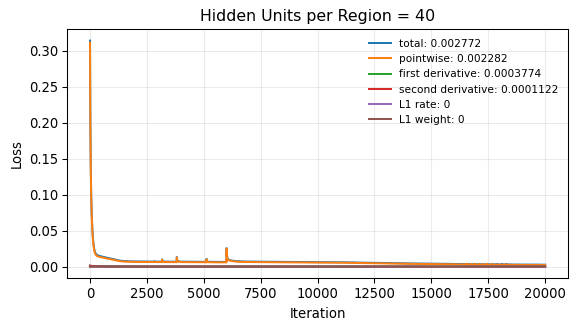

region_pcs seed=1420945627:   0%|          | 0/20000 [00:00<?, ?iter/s]

hidden_units=50; input_shape=(3, 100, 3); run_dir=/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/hidden_unit_sweep_region_pcs_condition_only_h050


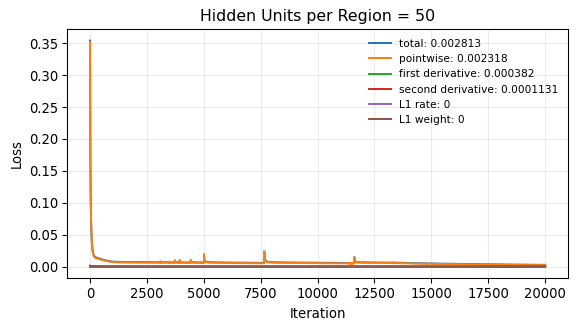

region_pcs seed=18676449:   0%|          | 0/20000 [00:00<?, ?iter/s]

hidden_units=60; input_shape=(3, 100, 3); run_dir=/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/hidden_unit_sweep_region_pcs_condition_only_h060


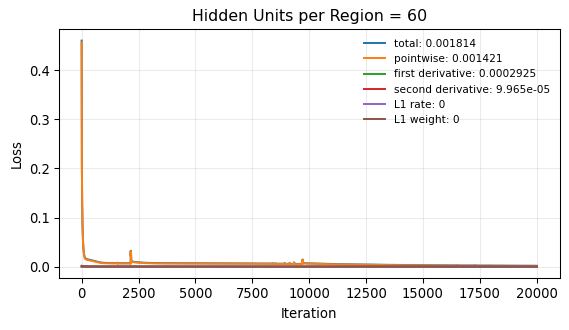

In [5]:
fits = []
for hidden_units in hidden_unit_grid:
    fit = train_hidden_unit_model(hidden_units)
    fits.append(fit)
    plot_loss(fit["result"]["history"], f"Hidden Units per Region = {hidden_units}")


## 6. Compare Fit Quality Across Hidden-Unit Counts

,hidden_units_per_region,total_hidden_units,trainable_parameters,n_scalar_observations,final_total_loss,final_reconstruction_loss,final_first_derivative_loss,final_second_derivative_loss,pointwise_sse,first_derivative_sse,second_derivative_sse,mean_r2,mean_correlation,mean_variance_ratio,aic_pointwise,bic_pointwise
0,40,160,33448,50400,0.002772,0.002282,0.000377,0.000112,114.484330,18.802219,5.537986,0.817291,0.903861,0.820563,-239904.348135,55366.115260
1,50,200,49768,50400,0.002813,0.002318,0.000382,0.000113,117.245847,19.037915,5.582057,0.815053,0.902354,0.820236,-206063.062858,233276.222667
2,60,240,69288,50400,0.001814,0.001421,0.000292,0.000100,71.063456,14.551871,4.912676,0.876333,0.935993,0.886581,-192258.330521,419398.565788


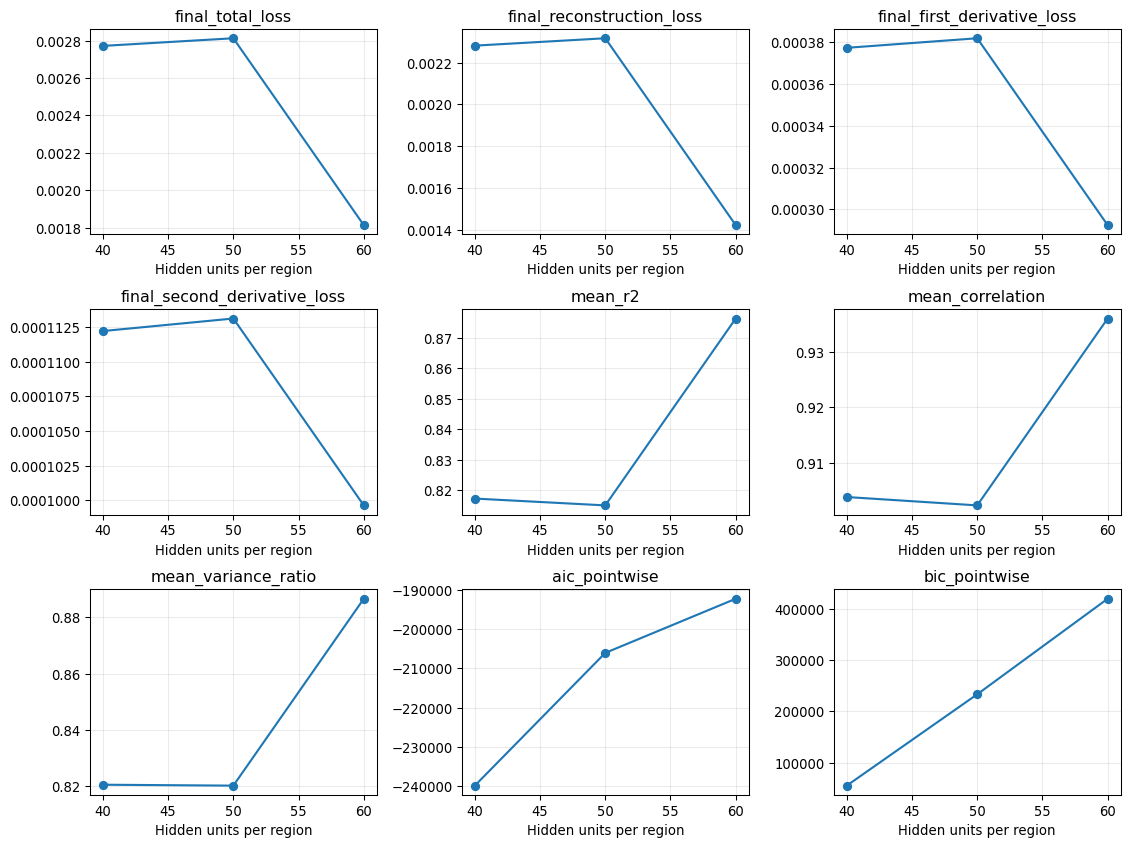

In [6]:
summary = pd.DataFrame([model_summary_row(fit) for fit in fits])
summary = summary.sort_values("hidden_units_per_region").reset_index(drop=True)
display(summary)

metric_columns = [
    "final_total_loss",
    "final_reconstruction_loss",
    "final_first_derivative_loss",
    "final_second_derivative_loss",
    "mean_r2",
    "mean_correlation",
    "mean_variance_ratio",
    "aic_pointwise",
    "bic_pointwise",
]
fig, axes = plt.subplots(3, 3, figsize=(12, 9), dpi=130)
for ax, metric in zip(axes.flat, metric_columns):
    ax.plot(summary["hidden_units_per_region"], summary[metric], marker="o", linewidth=1.6)
    ax.set_title(metric)
    ax.set_xlabel("Hidden units per region")
    ax.grid(alpha=0.25)
for ax in axes.flat[len(metric_columns):]:
    ax.axis("off")
fig.tight_layout()
display_figure(fig)


## 7. Top-PC Reconstruction Checks

These plots show observed and reconstructed trajectories for the top three PC targets in each region and fixation type. Observed traces are solid; mRNN reconstructions are dotted in the same condition color. Use these plots to check whether lower-dimensional models miss transient dynamics even when aggregate metrics are acceptable.

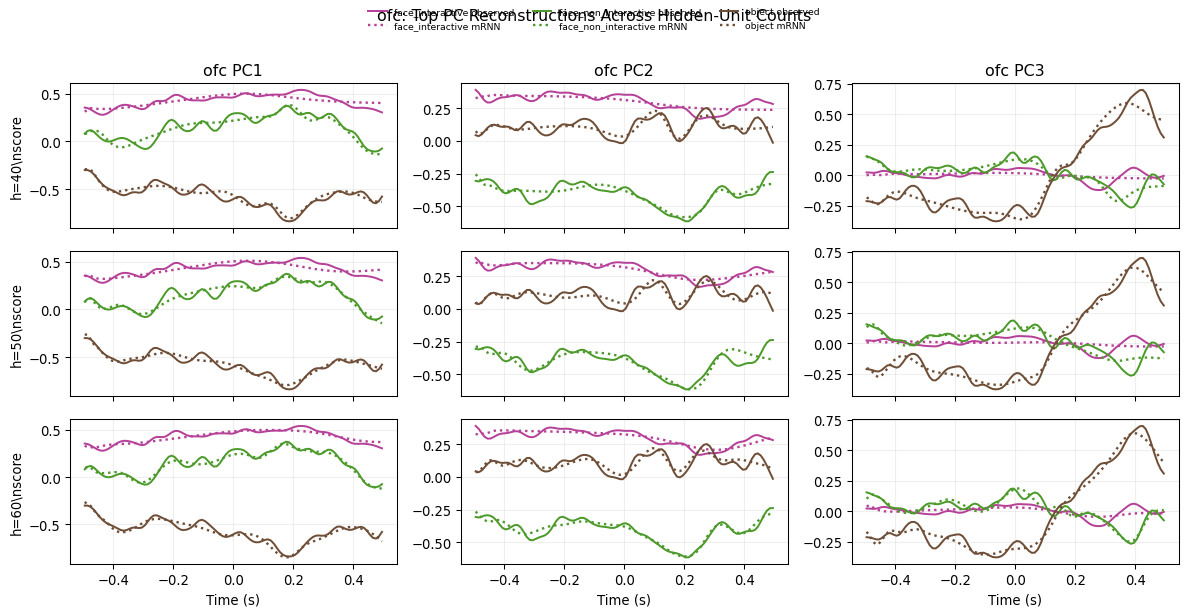

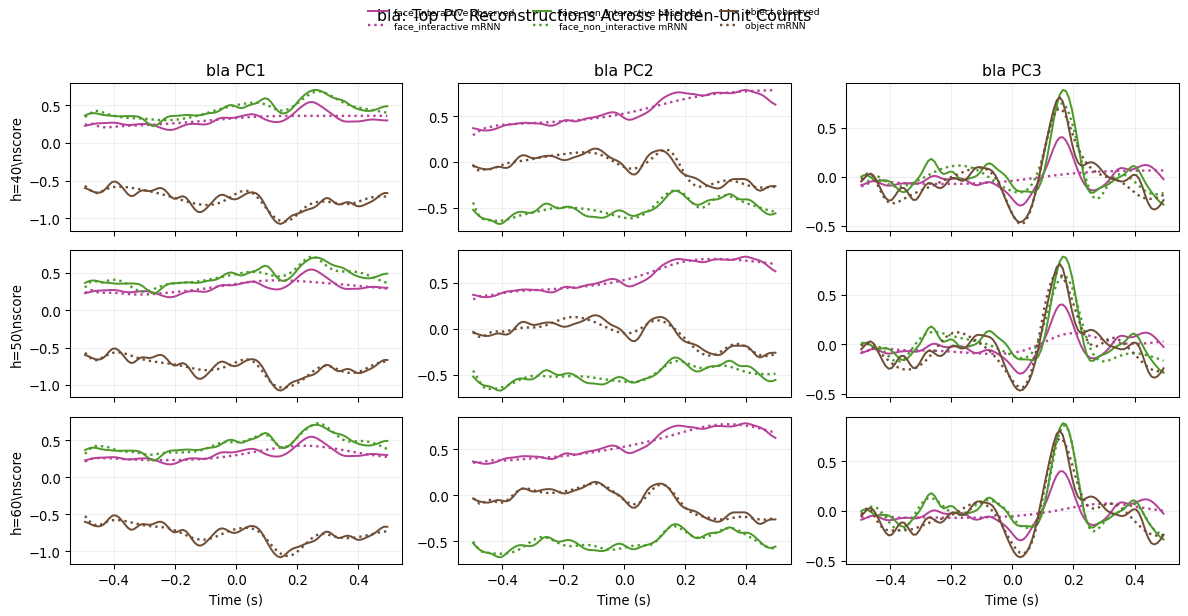

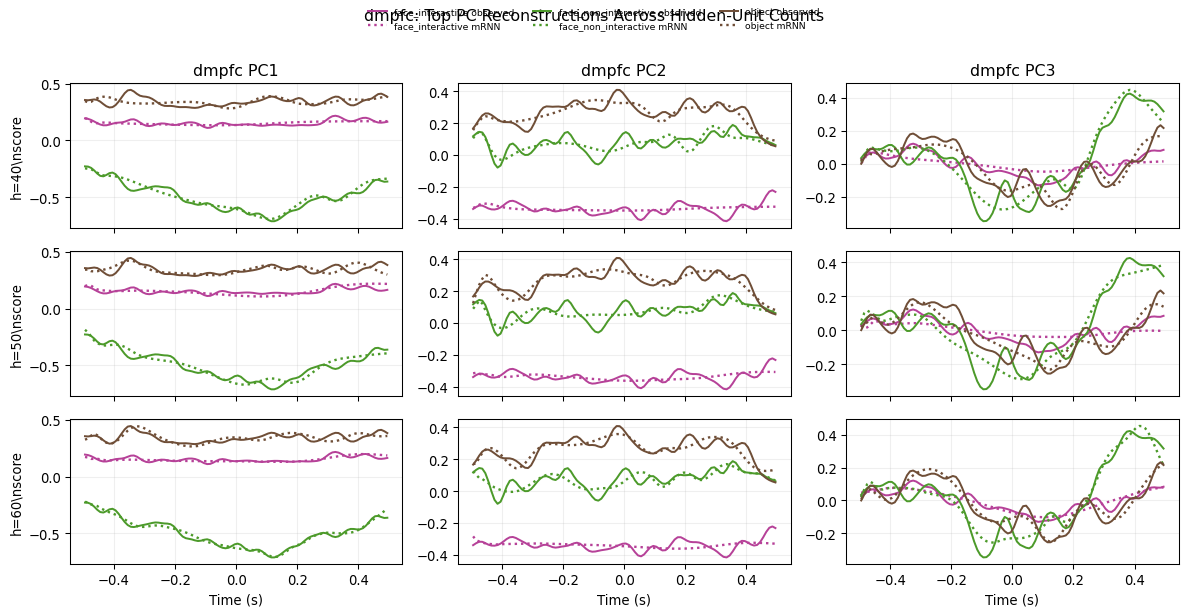

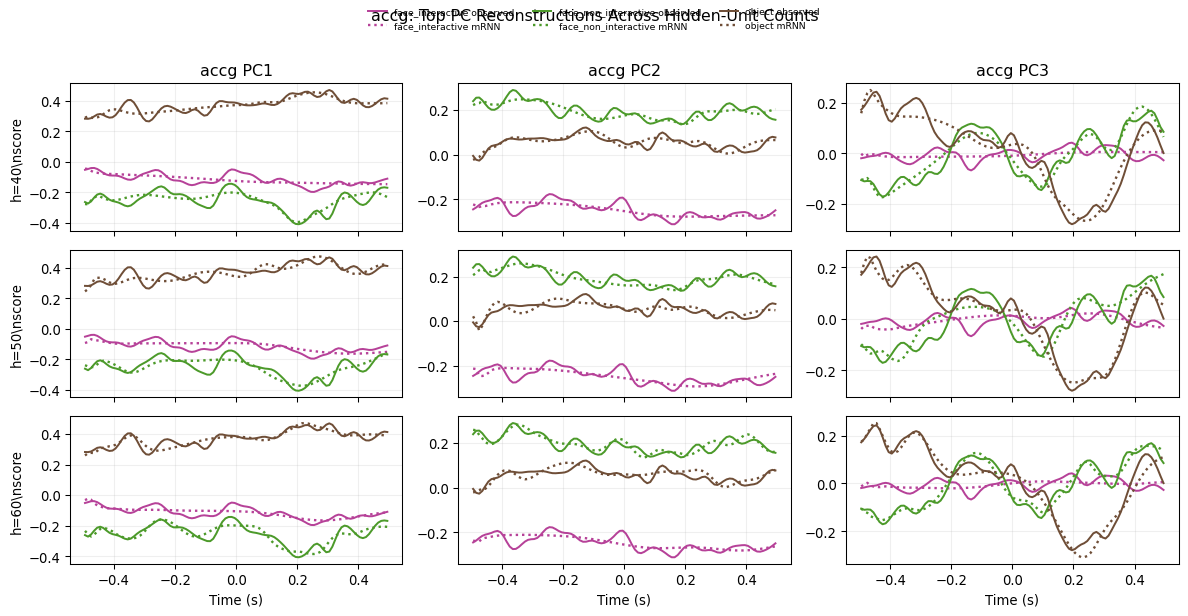

In [7]:
def plot_top_pc_reconstructions_by_hidden(fits, *, n_pcs=3):
    conditions = tuple(fits[0]["replay"]["condition_order"])
    regions = tuple(fits[0]["replay"]["region_order"])
    time = np.asarray(fits[0]["replay"]["checkpoint"]["timeline_s"], dtype=float)
    for region in regions:
        fig, axes = plt.subplots(
            len(fits),
            int(n_pcs),
            figsize=(4.2 * int(n_pcs), 2.1 * len(fits)),
            dpi=130,
            sharex=True,
            squeeze=False,
        )
        for row, fit in enumerate(fits):
            replay = fit["replay"]
            observed = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
            predicted = replay["output_by_region"][region].detach().cpu().numpy()
            for pc_idx in range(int(n_pcs)):
                ax = axes[row, pc_idx]
                for cond_idx, condition in enumerate(conditions):
                    color = CONDITION_COLORS.get(condition)
                    ax.plot(time, observed[cond_idx, :, pc_idx], color=color, linewidth=1.5, linestyle="-", label=f"{condition} observed")
                    ax.plot(time, predicted[cond_idx, :, pc_idx], color=color, linewidth=1.8, linestyle=":", label=f"{condition} mRNN")
                if row == 0:
                    ax.set_title(f"{region} PC{pc_idx + 1}")
                if pc_idx == 0:
                    ax.set_ylabel(f"h={fit['hidden_units']}\\nscore")
                if row == len(fits) - 1:
                    ax.set_xlabel("Time (s)")
                ax.grid(alpha=0.2)
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=7)
        fig.suptitle(f"{region}: Top PC Reconstructions Across Hidden-Unit Counts", y=1.02)
        fig.tight_layout()
        display_figure(fig)


plot_top_pc_reconstructions_by_hidden(fits, n_pcs=3)


## 8. Region- and Condition-Level Diagnostics

Aggregate metrics can hide region-specific failures. This section breaks reconstruction quality down by hidden-unit count, region, and fixation condition.

In [8]:
accuracy_rows = []
variance_rows = []
for fit in fits:
    h = fit["hidden_units"]
    acc = reconstruction_accuracy(fit["replay"]).assign(hidden_units_per_region=h)
    var = variance_comparison(fit["replay"]).assign(hidden_units_per_region=h)
    accuracy_rows.append(acc)
    variance_rows.append(var)
accuracy_by_fit = pd.concat(accuracy_rows, ignore_index=True)
variance_by_fit = pd.concat(variance_rows, ignore_index=True)

display(accuracy_by_fit)
display(variance_by_fit)

for metric in ["r2", "correlation", "mse"]:
    pivot = accuracy_by_fit.pivot_table(
        index=["region", "condition"],
        columns="hidden_units_per_region",
        values=metric,
    )
    print(metric)
    display(pivot)


,region,condition,mse,mae,r2,correlation,hidden_units_per_region
0,ofc,face_interactive,0.001338,0.029175,0.844734,0.919118,40
1,ofc,face_non_interactive,0.002980,0.041802,0.765276,0.874820,40
2,ofc,object,0.002914,0.041367,0.842621,0.917960,40
3,bla,face_interactive,0.002319,0.034323,0.833861,0.913181,40
4,bla,face_non_interactive,0.006003,0.059496,0.786625,0.886936,40
5,bla,object,0.004617,0.052129,0.841954,0.917584,40
6,dmpfc,face_interactive,0.000634,0.019521,0.851032,0.922517,40
7,dmpfc,face_non_interactive,0.001630,0.030989,0.857509,0.926041,40
8,dmpfc,object,0.001564,0.030762,0.823267,0.907370,40
9,accg,face_interactive,0.000592,0.019148,0.767489,0.876128,40


,region,observed_variance,reconstructed_variance,reconstructed_to_observed_ratio,hidden_units_per_region
0,ofc,0.013428,0.011032,0.821561,40
1,bla,0.024063,0.019831,0.824111,40
2,dmpfc,0.008286,0.006948,0.838549,40
3,accg,0.005290,0.004221,0.798032,40
4,ofc,0.013428,0.011121,0.828184,50
5,bla,0.024063,0.019458,0.808638,50
6,dmpfc,0.008286,0.006956,0.839523,50
7,accg,0.005290,0.004256,0.804599,50
8,ofc,0.013428,0.011828,0.880852,60
9,bla,0.024063,0.021502,0.893589,60


r2


hidden_units_per_region            40        50        60
region condition                                         
accg   face_interactive      0.767489  0.774408  0.795913
       face_non_interactive  0.765020  0.738737  0.884780
       object                0.828105  0.851380  0.873365
bla    face_interactive      0.833861  0.859191  0.863508
       face_non_interactive  0.786625  0.737521  0.916833
       object                0.841954  0.861049  0.889471
dmpfc  face_interactive      0.851032  0.844292  0.860542
       face_non_interactive  0.857509  0.831444  0.922425
       object                0.823267  0.828451  0.854734
ofc    face_interactive      0.844734  0.862703  0.879457
       face_non_interactive  0.765276  0.724275  0.890502
       object                0.842621  0.867185  0.884468

correlation


hidden_units_per_region            40        50        60
region condition                                         
accg   face_interactive      0.876128  0.880208  0.892147
       face_non_interactive  0.874662  0.859501  0.940632
       object                0.910010  0.922713  0.934620
bla    face_interactive      0.913181  0.926930  0.929270
       face_non_interactive  0.886936  0.858854  0.957520
       object                0.917584  0.927927  0.943121
dmpfc  face_interactive      0.922517  0.918889  0.927669
       face_non_interactive  0.926041  0.911838  0.960430
       object                0.907370  0.910194  0.924547
ofc    face_interactive      0.919118  0.928820  0.937819
       face_non_interactive  0.874820  0.851146  0.943684
       object                0.917960  0.931230  0.940462

mse


hidden_units_per_region            40        50        60
region condition                                         
accg   face_interactive      0.000592  0.000574  0.000519
       face_non_interactive  0.001514  0.001684  0.000743
       object                0.001153  0.000997  0.000849
bla    face_interactive      0.002319  0.001965  0.001905
       face_non_interactive  0.006003  0.007385  0.002340
       object                0.004617  0.004059  0.003229
dmpfc  face_interactive      0.000634  0.000663  0.000593
       face_non_interactive  0.001630  0.001928  0.000887
       object                0.001564  0.001519  0.001286
ofc    face_interactive      0.001338  0.001183  0.001039
       face_non_interactive  0.002980  0.003500  0.001390
       object                0.002914  0.002460  0.002139

## 9. Other Losses to Consider

The current objective already includes pointwise PC reconstruction, first derivative, and second derivative losses. Additional losses worth testing:

- Region-balanced loss: average each region's loss before summing, so regions with larger variance or harder PCs do not dominate.
- PC-weighted loss: weight PCs by explained variance if the top PCs should dominate, or inversely by variance if small PCs should be preserved.
- Variance-matching loss: penalize mismatch between reconstructed and observed variance within each region/condition, reducing flat-output solutions.
- Correlation loss: maximize temporal correlation between observed and reconstructed PC trajectories, useful when shape matters more than absolute scale.
- Spectral or frequency-domain loss: compare FFT power in low/mid/high temporal bands, encouraging the RNN to capture faster temporal variations.
- Peak/trough timing loss: penalize shifts in extrema or onset response peaks, if specific fixation-locked events are scientifically important.
- Autonomy penalty or input-ablation consistency: if we want less input-driven behavior, add diagnostics/losses that test whether hidden dynamics can continue trajectories after a brief cue.
- Mild L2 weight decay: controls parameter growth more smoothly than L1 sparsity and can help compare larger hidden-unit models.

For this hidden-unit sweep, AIC/BIC-style penalties plus visual top-PC checks should help decide whether extra hidden units buy real temporal reconstruction or only overparameterization.